In [1]:
import os
import sys 
sys.path.append(os.path.dirname("/Users/aborlaff/NASA/EPHESSOS/ephessos"))
import ephessos as ep

In [ ]:
NEA_elements_table = ep.core.read_mpc_nea_file("/Users/aborlaff/NASA/EPHESSOS/notebooks/NEA-test.txt")

i = 0 

from astropy.time import Time
mjd_start = Time('2020-01-01T00:00:00', format='isot', scale='utc').mjd
mjd_end = Time('2026-01-02T00:00:00', format='isot', scale='utc').mjd

if NEA_elements_table.iloc[i]["Epoch"] == "K25BL":
    epoch = Time('2025-11-21T00:00:00', format='isot', scale='tt').jd
    print(epoch)

horizons_dataframe = ep.core.ephessos(designation=NEA_elements_table.iloc[i]["Designation"], 
                      epoch=epoch, 
                      eccentricity=NEA_elements_table.iloc[i]["Eccentricity"], 
                      node=NEA_elements_table.iloc[i]["Node"], 
                      arg_perihelion=NEA_elements_table.iloc[i]["Arg_Perihelion"], 
                      inclination=NEA_elements_table.iloc[i]["Inclination"], 
                      mean_anomaly=NEA_elements_table.iloc[i]["Mean_Anomaly"], 
                      semimajor_axis=NEA_elements_table.iloc[i]["Semimajor_Axis"], 
                      mean_motion=NEA_elements_table.iloc[i]["Mean_Motion"], 
                      mjd_start=mjd_start, 
                      mjd_end=mjd_end, 
                      step_size="1d", 
                      verbose=True)

  Designation      H     G  Epoch  Mean_Anomaly  Arg_Perihelion       Node  \
0         433  10.38  0.15  K25BL     310.55432       178.92978  304.27008   
1         719  15.59  0.15  K25BL     240.61027       156.18940  183.86097   
2         887  13.82  0.15  K25BL      81.54059       350.53450  110.40588   
3        1036   9.18  0.15  K25BL      97.59385       132.50313  215.44119   
4        1221  17.37  0.15  K25BL      59.87047        26.75825  171.23717   

   Inclination  Eccentricity  Mean_Motion  ...  First_Obs  Last_Obs_Arc  \
0     10.82847      0.222836     0.559775  ...       1893          2025   
1     11.57311      0.546596     0.230218  ...       1911          2025   
2      9.40006      0.571170     0.253339  ...       1918          2025   
3     26.68073      0.533213     0.226551  ...       1924          2025   
4     11.86883      0.434632     0.370518  ...       1932          2025   

  RMS_Resid  Pert_Coarse  Pert_Precise  Comp_Name  Flags  Num_ID Full_Name  \
0 

In [ ]:
eros_horizons_dataframe = ep.core.ephessos(designation="00433", epoch=2461000.83333,
                      mjd_start=mjd_start, 
                      mjd_end=mjd_end, 
                      step_size="1d", 
                      verbose=True)

print(eros_horizons_dataframe)

--designation=00433 --epoch=2461000.83333 --eccentricity=None --node=None, --arg_perihelion=None --inclination=None --mean_anomaly=None --semimajor_axis=None --mean_motion=None --mjd_start=58849.0 --mjd_end=61042.0 --step_size=1d
https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND='00433'&OBJECT=00433&EPOCH=2461000.83333&ECLIP=J2000&OBJ_DATA='YES'&MAKE_EPHEM='YES'&EPHEM_TYPE='OBSERVER'&CENTER='500@399'&START_TIME='2020-01-01T00:00:00.000'&STOP_TIME='2026-01-02T00:00:00.000'&STEP_SIZE='1d'&CSV_FORMAT='YES'&QUANTITIES='1,2,3,4,5,6,7,8,9,10,20,23,24,25,27,29'
['2020-01-01 00:00' '2020-01-02 00:00' '2020-01-03 00:00' ...
 '2025-12-31 00:00' '2026-01-01 00:00' '2026-01-02 00:00']
       Date__(UT)__HR:MN         R.A._(ICRF)   DEC__(ICRF)    R.A.__(a-app)  \
0      2020-Jan-01 00:00         19 58 28.55   -20 15 08.8      19 59 36.04   
1      2020-Jan-02 00:00         20 00 53.61   -20 05 30.8      20 02 00.98   
2      2020-Jan-03 00:00         20 03 18.43   -19 55 45.4      20 04

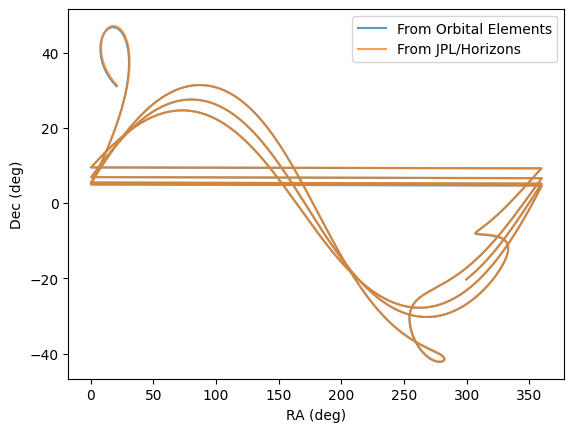

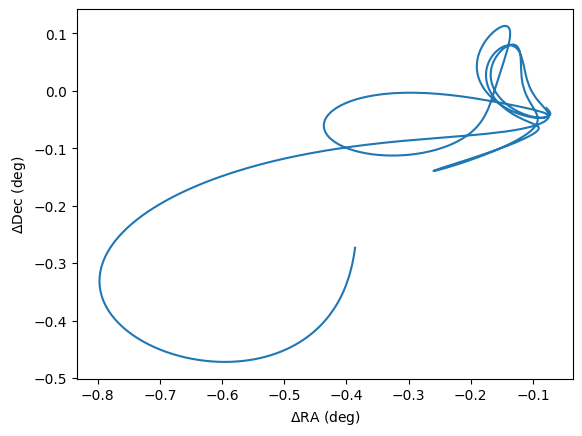

In [8]:
import matplotlib.pyplot as plt
plt.plot(horizons_dataframe["RA_deg_ICRF"], horizons_dataframe["DEC_deg_ICRF"], alpha=0.75, label="From Orbital Elements")
plt.plot(eros_horizons_dataframe["RA_deg_ICRF"], eros_horizons_dataframe["DEC_deg_ICRF"], alpha=0.75, label="From JPL/Horizons")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.legend() 
plt.savefig("horizons_vs_elements_comparison.png", dpi=300)
plt.show()


plt.plot(horizons_dataframe["RA_deg_ICRF"] - eros_horizons_dataframe["RA_deg_ICRF"], horizons_dataframe["DEC_deg_ICRF"] - eros_horizons_dataframe["DEC_deg_ICRF"])
plt.xlabel(r'$\Delta$RA (deg)')
plt.ylabel(r'$\Delta$Dec (deg)') 
plt.savefig("horizons_vs_elements_comparison_delta.png", dpi=300)
plt.show()
